In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [8]:
# Load the dataset
df = pd.read_csv(r'D:\Downloads\INTERNSHIP\House Price Prediction\House Price Prediction Dataset.csv')

# Display information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2000, 10)

First 5 rows:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   

In [9]:
# Data Preprocessing

def preprocess_data(df):
    """
    Preprocess the house price dataset
    """
    # Make a copy to avoid modifying original
    data = df.copy()
    
    # Handling missing values
    numerical_cols = data.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        data[col].fillna(data[col].median(), inplace=True)
    
    # For categorical columns, fill with mode
    categorical_cols = data.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        data[col].fillna(data[col].mode()[0], inplace=True)
    
    # Encode categorical variables
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        label_encoders[col] = le
    
    # Remove outliers in numerical features
    # Using IQR method for square footage/area and bedrooms
    if 'area' in data.columns or 'sqft' in data.columns:
        area_col = 'area' if 'area' in data.columns else 'sqft'
        Q1 = data[area_col].quantile(0.25)
        Q3 = data[area_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data = data[(data[area_col] >= lower_bound) & (data[area_col] <= upper_bound)]
    
    # Feature engineering
    if 'area' in data.columns and 'price' in data.columns:
        data['price_per_sqft'] = data['price'] / data['area']
    
    return data, label_encoders

# Apply preprocessing
df_processed, encoders = preprocess_data(df)
print("\nProcessed Data Shape:", df_processed.shape)
print("\nProcessed Data Info:")
print(df_processed.info())


Processed Data Shape: (2000, 10)

Processed Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   int64
 7   Condition  2000 non-null   int64
 8   Garage     2000 non-null   int64
 9   Price      2000 non-null   int64
dtypes: int64(10)
memory usage: 156.4 KB
None


In [12]:
# Feature Selection and scaling

# Separate features and target variable
target_column = 'Price'  # Your target column

# Select features (all columns except target and Id)
feature_columns = [col for col in df_processed.columns 
                   if col != target_column 
                   and col != 'Id']  # Exclude Id column

print("="*50)
print("FEATURE SELECTION")
print("="*50)
print(f"Target column: {target_column}")
print(f"\nFeature columns ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"{i}. {col}")

# Separate features and target
X = df_processed[feature_columns]
y = df_processed[target_column]

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")

# Check data types
print("\nFeature data types:")
print(X.dtypes)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Convert back to DataFrame for easier interpretation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_columns)

print("\nScaled training data statistics:")
print(X_train_scaled_df.describe())

FEATURE SELECTION
Target column: Price

Feature columns (8):
1. Area
2. Bedrooms
3. Bathrooms
4. Floors
5. YearBuilt
6. Location
7. Condition
8. Garage

Feature Matrix Shape: (2000, 8)
Target Vector Shape: (2000,)

Feature data types:
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location     int64
Condition    int64
Garage       int64
dtype: object

Training set size: 1600 samples
Test set size: 400 samples

Scaled training data statistics:
               Area      Bedrooms     Bathrooms        Floors     YearBuilt  \
count  1.600000e+03  1.600000e+03  1.600000e+03  1.600000e+03  1.600000e+03   
mean  -1.432188e-16 -1.665335e-16  8.659740e-17 -8.881784e-17 -1.518785e-15   
std    1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00  1.000313e+00   
min   -1.747253e+00 -1.416183e+00 -1.389361e+00 -1.236064e+00 -1.727818e+00   
25%   -8.746727e-01 -7.155358e-01 -4.875445e-01 -1.236064e+00 -8.922319e-01   
50%    2.138206e-04 -1.488875e-

In [16]:
#Model Training 

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, 
                                                   max_depth=5, 
                                                   random_state=42)
}

# Train and evaluate models
results = {}
predictions = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Store predictions
    predictions[name] = {'train': y_pred_train, 'test': y_pred_test}
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Store results
    results[name] = {
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }
    
    print(f"\n{name} Performance:")
    print(f"Train MAE: ${train_mae:,.2f}")
    print(f"Test MAE: ${test_mae:,.2f}")
    print(f"Train RMSE: ${train_rmse:,.2f}")
    print(f"Test RMSE: ${test_rmse:,.2f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

# Display results comparison
results_df = pd.DataFrame(results).T
print("\n" + "="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)
print(results_df.round(2))


Training Linear Regression...

Linear Regression Performance:
Train MAE: $237,404.10
Test MAE: $244,420.00
Train RMSE: $274,763.96
Test RMSE: $280,587.64
Train R²: 0.0067
Test R²: -0.0120

Training Gradient Boosting...

Gradient Boosting Performance:
Train MAE: $159,771.87
Test MAE: $252,712.52
Train RMSE: $191,299.17
Test RMSE: $295,272.70
Train R²: 0.5185
Test R²: -0.1207

MODEL PERFORMANCE COMPARISON
                   Train MAE   Test MAE  Train RMSE  Test RMSE  Train R2  \
Linear Regression  237404.10  244420.00   274763.96  280587.64      0.01   
Gradient Boosting  159771.87  252712.52   191299.17  295272.70      0.52   

                   Test R2  
Linear Regression    -0.01  
Gradient Boosting    -0.12  


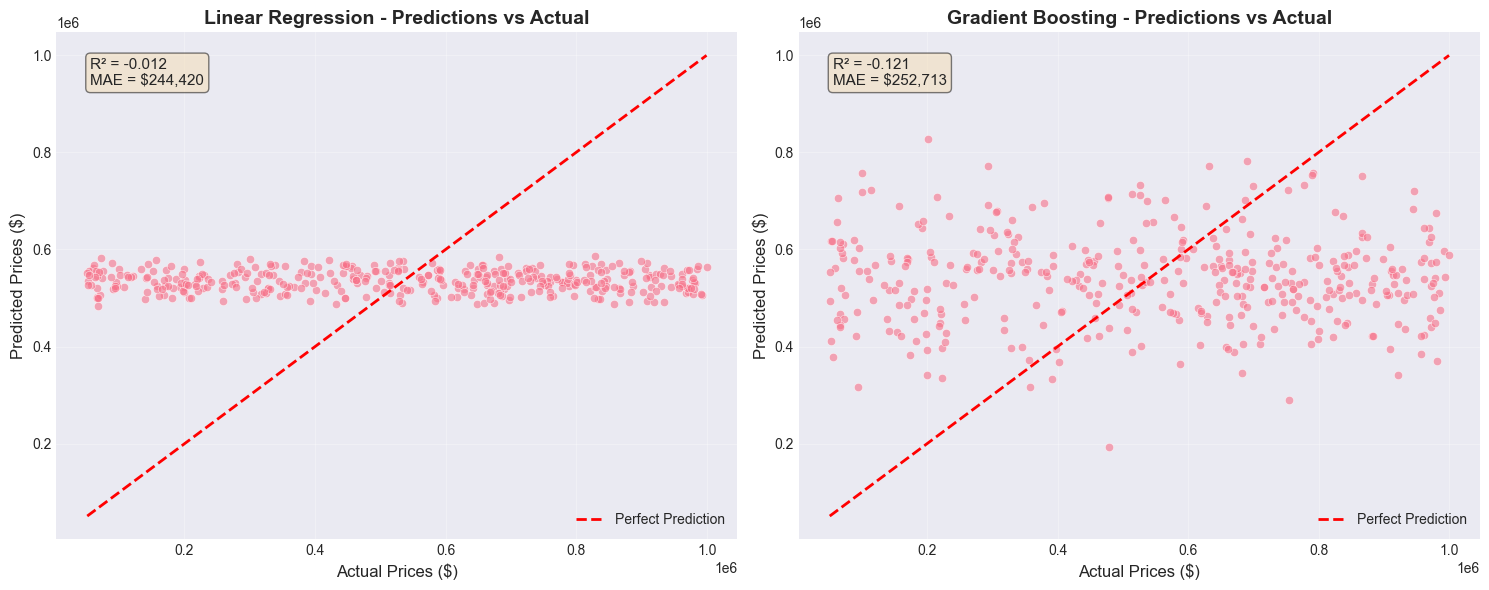

In [17]:
# Visualizations
# Create visualization for each model
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, (name, pred_dict) in enumerate(predictions.items()):
    ax = axes[idx]
    
    # Scatter plot for test predictions
    ax.scatter(y_test, pred_dict['test'], alpha=0.6, edgecolors='w', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(y_test.min(), pred_dict['test'].min())
    max_val = max(y_test.max(), pred_dict['test'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Prices ($)', fontsize=12)
    ax.set_ylabel('Predicted Prices ($)', fontsize=12)
    ax.set_title(f'{name} - Predictions vs Actual', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add metrics
    test_r2 = results[name]['Test R2']
    test_mae = results[name]['Test MAE']
    ax.text(0.05, 0.95, f'R² = {test_r2:.3f}\nMAE = ${test_mae:,.0f}', 
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()